In [3]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

### Non augmented

In [4]:
CLEANED_EXERCISE_PATH = "/home/svs/Workdir/gestures/gestures/notebooks/out/training/"

In [5]:
excersise_files = sorted(glob.glob(os.path.join(CLEANED_EXERCISE_PATH, "*.csv")))
print(excersise_files)

['/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.0.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.100.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.101.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.102.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.104.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.105.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.106.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.107.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.108.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.109.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.11.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.111.csv', '/home/svs/Workdir/gestures/gestures/notebooks/out/training/curl.112.csv', '/home/svs/Workdir/gestures

In [6]:
df = pd.read_csv(excersise_files[1])

In [7]:
tSec = (df['timestamp'] - df['timestamp'].iloc[0])/1000

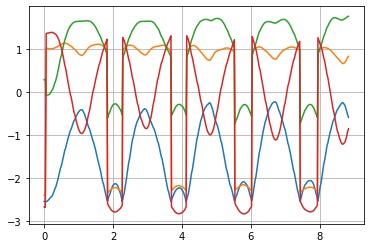

In [8]:
plt.plot(tSec, df['q0'], label='q0')
plt.plot(tSec, df['q1'], label='q1')
plt.plot(tSec, df['q2'], label='q2')
plt.plot(tSec, df['q3'], label='q3')
plt.grid()

### Augmentation

#### Time scaling

In [41]:
def scale_time(df, time_column, scale_range=(1.1, 1.2)):
    """Scales the time column of the DataFrame by a random factor within scale_range."""
    # Generate a random scaling factor from the specified range
    scale_factor = 1.2 #np.random.uniform(*scale_range)
    print(f"Scale factor: {scale_factor}")  # Print the scaling factor for verification

    # Create a new DataFrame to avoid modifying the original
    scaled_df = df.copy()
    # Update the values in the time column by multiplying them by the scaling factor
    scaled_df[time_column] = df[time_column] * scale_factor

    return scaled_df

In [35]:
df_aug = scale_time(df.copy(), 'timestamp')
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

Scale factor: 1.1210647703683359


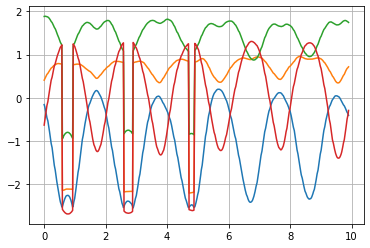

In [36]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

#### Rotation points

In [12]:
def rotate_points(x, y, angle, center_x, center_y):
    """Rotate points by a given angle around a custom center."""
    angle_rad = np.radians(angle)
    cos_val, sin_val = np.cos(angle_rad), np.sin(angle_rad)
    x_centered, y_centered = x - center_x, y - center_y
    x_rotated = cos_val * x_centered - sin_val * y_centered + center_x
    y_rotated = sin_val * x_centered + cos_val * y_centered + center_y
    return x_rotated, y_rotated

def apply_rotation(df, columns, angle):
    """Apply rotation transformation to specified columns."""
    # Определение центра вращения (среднее значение столбцов)
    center_x, center_y = df[columns[0]].mean(), df[columns[1]].mean()
    
    # Применение функции вращения
    x_rotated, y_rotated = rotate_points(df[columns[0]], df[columns[1]], angle, center_x, center_y)
    df[columns[0]] = x_rotated
    df[columns[1]] = y_rotated
    return df

In [13]:
rotation_angle=90
df_aug = apply_rotation(df.copy(), ['q0', 'q1', 'q2', 'q3'], rotation_angle)
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

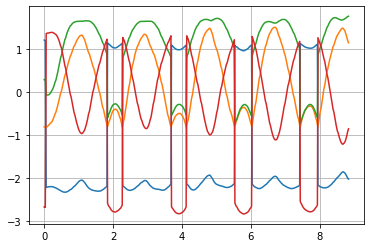

In [14]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

#### Data scaling

In [37]:
def apply_scaling(df, columns, scale_factor):
    """Apply scaling transformation to specified columns."""
    df[columns] *= scale_factor
    return df

In [38]:
scale_var=0.1
scale_factor = 1 + np.random.uniform(-scale_var, scale_var)
augment_cols = df.columns[1:]
df_aug = apply_scaling(df.copy(), augment_cols, scale_factor)
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

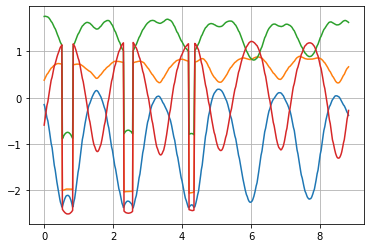

In [39]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

#### Add noise

In [18]:
def add_noise(df, columns, noise_level):
    """Add Gaussian noise to specified columns."""
    noise = np.random.normal(loc=0.0, scale=noise_level, size=df[columns].shape)
    df[columns] += noise
    return df

In [19]:
noise_level=0.02
augment_cols = df.columns[1:]
df_aug = add_noise(df.copy(), augment_cols, noise_level)
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

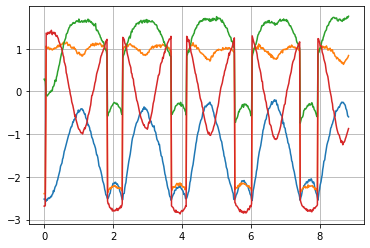

In [20]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

#### Augment_motion_data

In [9]:
def augment_motion_data(df, scale_factor):
    # Ensure scale_factor is greater than 1 to slow down motion
    if scale_factor <= 1:
        raise ValueError("Scale factor must be greater than 1 to slow down the motion.")
    
    # Create a new DataFrame for the interpolated data
    original_length = len(df)
    new_length = int(original_length * scale_factor)
    original_indices = np.arange(original_length)
    new_indices = np.linspace(0, original_length - 1, new_length)
    
    augmented_df = pd.DataFrame(index=np.arange(new_length))
    augmented_df['timestamp'] = np.linspace(df['timestamp'].iloc[0], df['timestamp'].iloc[-1], new_length)
    
    # Interpolate each column except 'timestamp'
    for col in df.columns[1:]:
        augmented_df[col] = np.interp(new_indices, original_indices, df[col])
    
    return augmented_df

In [10]:
df_aug = augment_motion_data(df.copy(), scale_factor=2)
tSec_aug = (df_aug['timestamp'] - df_aug['timestamp'].iloc[0])/1000

In [11]:
df_aug

,timestamp,ax,ay,az,q0,q1,q2,q3
0,6.465239e+06,0.948946,-0.854857,-0.404935,-2.546339,-2.406900,0.283699,-2.674993
1,6.465248e+06,0.957467,-0.870658,-0.401113,-2.548453,-2.403099,0.286216,-2.677735
2,6.465257e+06,0.965988,-0.886459,-0.397292,-2.550567,-2.399297,0.288733,-2.680478
3,6.465266e+06,0.973294,-0.892056,-0.403958,-2.550571,-2.396761,0.291250,-2.683220
4,6.465274e+06,0.980597,-0.897633,-0.410646,-2.550571,-2.394226,0.293767,-2.685962
...,...,...,...,...,...,...,...,...
995,6.474043e+06,-1.329460,-0.225821,-0.982942,-0.485502,0.774277,1.740005,-0.989443
996,6.474051e+06,-1.295377,-0.205372,-1.069886,-0.510868,0.786948,1.745039,-0.957907
997,6.474060e+06,-1.261221,-0.184844,-1.156890,-0.536238,0.799620,1.750071,-0.926366
998,6.474069e+06,-1.190620,-0.124428,-1.273453,-0.563718,0.812291,1.753846,-0.892088


In [12]:
df

,timestamp,ax,ay,az,q0,q1,q2,q3
0,6465239.0,0.948946,-0.854857,-0.404935,-2.546339,-2.406900,0.283699,-2.674993
1,6465256.0,0.966005,-0.886491,-0.397284,-2.550571,-2.399290,0.288738,-2.680483
2,6465272.0,0.980626,-0.897655,-0.410673,-2.550571,-2.394216,0.293777,-2.685973
3,6465298.0,0.985500,-0.817640,-0.445103,-2.550571,1.020294,-0.071555,1.354653
4,6465314.0,0.947728,-0.862300,-0.448929,-2.546339,1.015221,-0.074074,1.360143
...,...,...,...,...,...,...,...,...
495,6474003.0,-1.435604,-0.419427,-0.613428,-0.392298,0.723491,1.717309,-1.093879
496,6474020.0,-1.351529,-0.406401,-0.818095,-0.438849,0.748858,1.729907,-1.044469
497,6474036.0,-1.329597,-0.225902,-0.982594,-0.485400,0.774226,1.739985,-0.989569
498,6474052.0,-1.261362,-0.184965,-1.156656,-0.536183,0.799594,1.750063,-0.926434


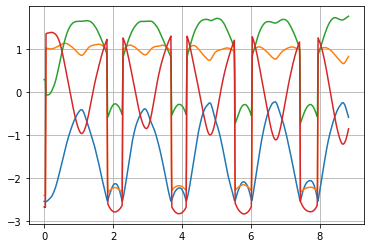

In [13]:
plt.plot(tSec_aug, df_aug['q0'], label='q0')
plt.plot(tSec_aug, df_aug['q1'], label='q1')
plt.plot(tSec_aug, df_aug['q2'], label='q2')
plt.plot(tSec_aug, df_aug['q3'], label='q3')

plt.grid()

## Augment exercises dataset

In [14]:
for i, file_path in enumerate(excersise_files):
    csv_filename = os.path.basename(file_path)
    path = os.path.dirname(file_path)

    df = pd.read_csv(file_path)
    
    # prepare augmented filename
    _, file = os.path.split(csv_filename)
    res = file.split('.')    
    aug_file_name = res[0] + '.' + 'aug_' + res[1] + '.' + res[2]
    full_aug_name = os.path.join('/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/', aug_file_name) #path
    
    # augment data from input file
    df_aug = augment_motion_data(df.copy(), scale_factor=2)    
    print(full_aug_name)
    # save augmented data
    df_aug.to_csv(full_aug_name, index=False)

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_0.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_100.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_101.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_102.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_104.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_105.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_106.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_107.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_108.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_109.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_11.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/curl.aug_111.csv
/home/svs/Workdir/gestures/gestures/noteboo

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_100.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_103.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_104.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_105.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_106.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_108.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_109.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_11.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_111.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_112.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/dumbell_row.aug_113.csv
/home/svs/Workdir/gestures/gestures/notebook

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_165.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_166.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_167.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_168.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_177.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_178.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_18.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_180.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_182.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_185.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/front_raise.aug_2.csv
/home/svs/Workdir/gestures/gestures/notebooks/

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_146.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_148.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_149.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_16.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_18.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_20.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_25.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_26.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_27.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_28.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/hammer_curl.aug_30.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/t

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_2975ba4c.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_2a311e7d.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_2ba76d98.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_2bedf0e9.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_2d4a266d.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_2eb2c8e4.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_2ece947e.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_30c2d89f.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_3127ad84.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_3138a078.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exe

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_6dc51422.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_6ddccd30.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_70291c36.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_70bc8065.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_71df3d8d.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_7249eadb.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_74238d59.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_74d022ee.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_751355f7.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_7539cf7b.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exe

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_ad258fc3.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_ad9fa5b2.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_af13c9a1.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_af87cccc.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_afdb848f.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_b02892d0.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_b118e9e1.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_b1552dbb.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_b170813d.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_b1fe228f.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exe

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_e63729c4.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_e6f60327.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_e7960013.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_ea22458d.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_ea4bb7eb.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_ea59bca1.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_ea914d7e.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_ec57d80e.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_ee9913d3.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exersice.aug_eecf9ae9.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/non_exe

/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_49.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_5.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_50.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_51.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_52.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_53.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_54.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_55.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_6.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_60.csv
/home/svs/Workdir/gestures/gestures/notebooks/out/training_aug/shoulder_press.aug_61.csv
/home/svs/Workdir/gestu